This notebook runs best on an L4 GPU in Google Colab

# CS274P Project: Chemical Reaction Prediction
**Main method in this notebook:** Graph Neural Network (GNN)

Outline:
- Load USPTO MIT dataset
- Convert SMILES representations into graph representations
- Pass the reactant + reagent graphs as inputs into the GNN model
- For all possible pairs of atoms from the input, the GNN outputs a prediction of whether those two atoms will be bonded together in the product, and what type of bond
- Raytune hyperparameter tuning
- Training loop for 10 epochs
- Evaluate the model by constructing the predicted graphs and comparing them against the graphs of the target products. Graph similarity and perfect match accuracy are the two main evaluation metrics. Also convert output graphs into canonicalized SMILES representation whenever possible, and compare it to the canonicalized SMILES of the true product, just to be certain that they match, as an extra verification of the perfect match accuracy
- Plot the training metrics, and generate some visuzalizations of randomly selected reaction predictions from the evaluation run, as well as some visualizations of perfect match predictions.


## 1. Imports and project paths

In [ ]:
%pip install rdkit
%pip install torch_geometric
%pip install torchmetrics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import rdkit
import torch_geometric
import json
import math
import random
import re
import time
import zipfile
from collections import Counter
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any, List

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.info')
RDLogger.DisableLog('rdApp.error')

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw" / "uspto_mit"
PROCESSED_DIR = DATA_DIR / "processed" / "uspto_mit"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "uspto_mit_gnn"


RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("GNN output directory:", OUTPUT_DIR)



Project directory: /content
Raw data directory: /content/data/raw/uspto_mit
Processed data directory: /content/data/processed/uspto_mit
GNN output directory: /content/outputs/uspto_mit_gnn


## 2. Reproducibility and device selection

In [3]:
SEED = 274


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility. They can make training slightly slower.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_seed(SEED)
DEVICE = pick_device()
print("Using device:", DEVICE)


Using device: cuda


## 3. Download USPTO-MIT

In [4]:
USPTO_MIT_URL = "https://github.com/wengong-jin/nips17-rexgen/raw/master/USPTO/data.zip"
zip_path = RAW_DIR / "data.zip"


def download_file(url: str, dest: Path):
    if dest.exists() and dest.stat().st_size > 0:
        print(f"Already exists: {dest}")
        return

    print(f"Downloading from {url}")
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    total = int(response.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    print(f"Saved to {dest}")


download_file(USPTO_MIT_URL, zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(RAW_DIR)

print("Extracted files:")
for path in sorted(RAW_DIR.rglob("*"))[:50]:
    print(" -", path.relative_to(RAW_DIR))

  0%|          | 0.00/49.7M [00:00<?, ?B/s]

Saved to /content/data/raw/uspto_mit/data.zip
Extracted files:
 - data
 - data/test.txt
 - data/train.txt
 - data/valid.txt
 - data.zip


## 4. Inspect the extracted files

The expected split files are usually `train.txt`, `dev.txt`, and `test.txt`.  
This cell searches recursively so the notebook still works if the files are nested.

In [5]:
txt_files = sorted(RAW_DIR.rglob("*.txt"))
file_info = []
for p in txt_files:
    try:
        size_mb = p.stat().st_size / (1024 ** 2)
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            first_line = f.readline().strip()
        file_info.append({
            "path": str(p.relative_to(RAW_DIR)),
            "size_mb": round(size_mb, 2),
            "first_line_preview": first_line[:120],
        })
    except Exception as e:
        file_info.append({"path": str(p.relative_to(RAW_DIR)), "error": str(e)})

pd.DataFrame(file_info)

,path,size_mb,first_line_preview
0,data/test.txt,18.60,[CH2:23]1[O:24][CH2:25][CH2:26][CH2:27]1.[F:1]...
1,data/train.txt,189.95,[CH2:15]([CH:16]([CH3:17])[CH3:18])[Mg+:19].[C...
2,data/valid.txt,13.90,[CH3:15][C:16](=[O:17])[CH3:18].[CH3:3][O:4][c...


## 5. Graph Data Representation and SMILES Parsing

We need to convert the SMILES strings into a format suitable for Graph Neural Networks. This involves:
1.  **Atom Features**: Representing chemical identity (atomic number, charge, etc.).
2.  **Edge Features**: Representing bond types.
3.  **Atom Mapping**: Tracking the `molAtomMapNumber` provided in the USPTO dataset to identify how reactant atoms correspond to product atoms.

In [6]:
from torch_geometric.data import Data
from rdkit import Chem
import torch

SUPPORTED_ATOMS = [6, 7, 8, 9, 15, 16, 17, 35, 53, 5, 14, 1, 3, 11, 12, 19, 20]
HYBRIDIZATION_TYPES = [Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D, Chem.rdchem.HybridizationType.SP3D2]

def one_hot_encoding(value, choices):
    encoding = [0] * (len(choices) + 1)
    try:
        index = choices.index(value)
        encoding[index] = 1
    except ValueError:
        encoding[-1] = 1
    return encoding

def get_atom_features(atom):
    features = []
    features.extend(one_hot_encoding(atom.GetAtomicNum(), SUPPORTED_ATOMS))
    features.extend(one_hot_encoding(atom.GetHybridization(), HYBRIDIZATION_TYPES))
    features.extend([atom.GetTotalDegree(), atom.GetFormalCharge(), atom.GetTotalNumHs(), int(atom.GetIsAromatic())])
    return features

def get_bond_features(bond):
    bt = bond.GetBondType()
    fbond = [bt == Chem.rdchem.BondType.SINGLE, bt == Chem.rdchem.BondType.DOUBLE, bt == Chem.rdchem.BondType.TRIPLE, bt == Chem.rdchem.BondType.AROMATIC]
    return fbond.index(True) + 1 if True in fbond else 0

def reaction_to_graph(rxn_smiles):
    try:
        parts = rxn_smiles.split('>>')
        reactant_smiles, product_smiles = parts[0], parts[1].split(' ')[0]
        r_mol = Chem.MolFromSmiles(reactant_smiles)
        p_mol = Chem.MolFromSmiles(product_smiles)
        if r_mol is None or p_mol is None: return None

        # 1. Node Features
        atom_features = [get_atom_features(a) for a in r_mol.GetAtoms()]

        # Identify all atoms in reactants that have a mapping
        r_map_to_idx = {a.GetAtomMapNum(): a.GetIdx() for a in r_mol.GetAtoms() if a.GetAtomMapNum() > 0}
        mapped_nums = sorted(list(r_map_to_idx.keys()))
        num_mapped = len(mapped_nums)

        # 2. Reactant Edges (for GNN input)
        edge_index, edge_attr = [], []
        for b in r_mol.GetBonds():
            i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
            attr = b_attr = get_bond_features(b)
            edge_index.extend([[i, j], [j, i]])
            edge_attr.extend([attr, attr])

        # 3. Ground Truth Targets (Dense grid for mapped subset)
        adj_targets = torch.zeros((num_mapped, num_mapped), dtype=torch.long)

        # Product mapping
        p_map_to_idx = {a.GetAtomMapNum(): a.GetIdx() for a in p_mol.GetAtoms() if a.GetAtomMapNum() > 0}

        for b in p_mol.GetBonds():
            m1, m2 = b.GetBeginAtom().GetAtomMapNum(), b.GetEndAtom().GetAtomMapNum()
            if m1 in r_map_to_idx and m2 in r_map_to_idx:
                i_mapped = mapped_nums.index(m1)
                j_mapped = mapped_nums.index(m2)
                attr = get_bond_features(b)
                adj_targets[i_mapped, j_mapped] = attr
                adj_targets[j_mapped, i_mapped] = attr

        # 4. CRITICAL FIX: Build explicit absolute coordinate pairs matching adj_targets layout
        # This maps the absolute row indices of 'h' to the exact flat sequence of 'y'
        mapped_absolute_indices = [r_map_to_idx[m] for m in mapped_nums]

        row_coords = []
        col_coords = []
        for i in range(num_mapped):
            for j in range(num_mapped):
                row_coords.append(mapped_absolute_indices[i])
                col_coords.append(mapped_absolute_indices[j])

        candidate_pairs = torch.tensor([row_coords, col_coords], dtype=torch.long)

        return Data(
            x=torch.tensor(atom_features, dtype=torch.float),
            edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
            edge_attr=torch.tensor(edge_attr, dtype=torch.long),
            mapping=torch.tensor([a.GetAtomMapNum() for a in r_mol.GetAtoms()], dtype=torch.long),
            candidate_pairs=candidate_pairs, # Shape: [2, num_mapped^2]
            y=adj_targets.view(-1)             # Shape: [num_mapped^2]
        )
    except Exception: return None

### 5.1 Processing the Dataset

Now we apply the parsing function to the entire dataset. We will skip any reactions that RDKit cannot process and store the resulting PyG `Data` objects in lists for each split.

In [7]:
def process_txt_file(file_path):
    """Reads a txt file and converts each reaction SMILES to a graph, skipping failures."""
    graphs = []
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in tqdm(lines, desc=f"Processing {file_path.name}"):
            smiles = line.strip()
            if not smiles:
                continue
            graph = reaction_to_graph(smiles)
            if graph is not None:
                graphs.append(graph)
    return graphs

# Process all splits
train_graphs = process_txt_file(RAW_DIR / "data/train.txt")
valid_graphs = process_txt_file(RAW_DIR / "data/valid.txt")
test_graphs = process_txt_file(RAW_DIR / "data/test.txt")

print(f"\nProcessing complete:")
print(f"Train: {len(train_graphs)} graphs")
print(f"Valid: {len(valid_graphs)} graphs")
print(f"Test: {len(test_graphs)} graphs")

Processing train.txt:   0%|          | 0/409035 [00:00<?, ?it/s]

Processing valid.txt:   0%|          | 0/30000 [00:00<?, ?it/s]

Processing test.txt:   0%|          | 0/40000 [00:00<?, ?it/s]


Processing complete:
Train: 409006 graphs
Valid: 29998 graphs
Test: 39994 graphs


## 6. GNN Model Architecture (GATv2)

We will use a Graph Attention Network (GATv2) to encode the reactants.

### Pairwise Prediction Logic:
1. **Encoder**: GATv2 layers update atom features based on their chemical environment.
2. The network generates predictions for all pairs of atoms, predicting what type of bond they will have in the output (none, single, double, triple, or aromatic).

In [8]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class ReactionGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes=5, heads=4):
        super(ReactionGNN, self).__init__()
        self.hidden_dim = hidden_dim

        # GATv2 Layers
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=heads, edge_dim=1)
        self.conv2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=heads, edge_dim=1)

        # MLP for pairwise bond prediction
        self.bond_predictor = nn.Sequential(
            nn.Linear(hidden_dim * heads * 4, hidden_dim * 4),
            nn.ReLU(),
            nn.Linear(hidden_dim * 4, num_classes)
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # 1. Node Encoding via GNN (Processes the entire super-graph instantly)
        h = F.relu(self.conv1(x, edge_index, edge_attr.unsqueeze(-1).float()))
        h = self.conv2(h, edge_index, edge_attr.unsqueeze(-1).float())

        # 2. Extract perfectly pre-aligned candidate pairs
        # These indices are already offset and mapped to match 'data.y' exactly
        row, col = data.candidate_pairs[0], data.candidate_pairs[1]

        # 3. Vectorized Pairwise Feature Gathering
        diff = torch.abs(h[row] - h[col])
        mult = h[row] * h[col]
        pair_features = torch.cat([h[row], h[col], diff, mult], dim=-1)

        # 4. Predict logits for all pairs across the entire batch simultaneously
        logits = self.bond_predictor(pair_features)

        return logits

# Instantiate model
model = ReactionGNN(input_dim=28, hidden_dim=128).to(DEVICE)
print(model)

ReactionGNN(
  (conv1): GATv2Conv(28, 128, heads=4)
  (conv2): GATv2Conv(512, 128, heads=4)
  (bond_predictor): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=5, bias=True)
  )
)


## 7. Training Loop and Dynamic Weighted Loss

To handle the extreme sparsity of the product graphs, we calculate class weights dynamically for every batch:
1.  **Targets**: For every batch, we determine the ground-truth bond types between all pairs of mapped atoms.
2.  **Weights**: We calculate the frequency of each bond type (0-4) and use the inverse frequency to weight the Cross-Entropy loss. Also include a hyperparameter called PRECISION_FACTOR, which serves as a multiplicative factor for the weights, in case ratio calculation alone is not enough to sufficiently balance the model's accuracy and precision.

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

from torch.utils.data import DataLoader as StandardDataLoader
from torch_geometric.data import Batch
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall
from tqdm.auto import tqdm

def evaluate(model, loader, device, precision_factor=0.25, use_tqdm=False):
    model.eval()
    total_loss = 0
    acc_metric = MulticlassAccuracy(num_classes=5, average='micro').to(device)
    precision_metric = MulticlassPrecision(num_classes=5, average='macro').to(device)
    recall_metric = MulticlassRecall(num_classes=5, average='macro').to(device)

    loop_iterable = tqdm(loader, desc="Evaluating") if use_tqdm else loader

    with torch.no_grad():
        for batch in loop_iterable:
            batch = batch.to(device)
            logits = model(batch)
            if not hasattr(batch, 'y') or batch.y is None:
                continue
            targets = batch.y

            counts = torch.bincount(targets, minlength=5).float()
            weights = torch.ones(5, device=device)

            for idx in range(1, 5):
                if counts[idx] > 0:
                    weights[idx] = torch.clamp((counts[0] / (counts[idx] + 1e-6)) * precision_factor, min=1.0, max=15.0)
                else:
                    weights[idx] = 15.0

            loss = F.cross_entropy(logits, targets, weight=weights)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            acc_metric.update(preds, targets)
            precision_metric.update(preds, targets)
            recall_metric.update(preds, targets)

    return {
        "loss": total_loss / len(loader),
        "acc": acc_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item()
    }

def train_one_epoch_with_metrics(model, loader, optimizer, device, precision_factor=0.25, use_tqdm=False, log_interval=100):
    model.train()
    total_loss = 0
    batch_history = []

    acc_metric = MulticlassAccuracy(num_classes=5, average='micro').to(device)
    precision_metric = MulticlassPrecision(num_classes=5, average='macro').to(device)
    recall_metric = MulticlassRecall(num_classes=5, average='macro').to(device)

    loop_iterable = tqdm(loader, desc="Training") if use_tqdm else loader

    for i, batch in enumerate(loop_iterable):
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch)
        if not hasattr(batch, 'y') or batch.y is None:
            continue
        targets = batch.y

        counts = torch.bincount(targets, minlength=5).float()
        weights = torch.ones(5, device=device)

        for idx in range(1, 5):
            if counts[idx] > 0:
                weights[idx] = torch.clamp((counts[0] / (counts[idx] + 1e-6)) * precision_factor, min=1.0, max=15.0)
            else:
                weights[idx] = 15.0

        loss = F.cross_entropy(logits, targets, weight=weights)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        acc_metric.update(preds, targets)
        precision_metric.update(preds, targets)
        recall_metric.update(preds, targets)

        if log_interval > 0 and (i + 1) % log_interval == 0:
            batch_history.append({
                "loss": loss.item(),
                "acc": acc_metric.compute().item(),
                "precision": precision_metric.compute().item(),
                "recall": recall_metric.compute().item()
            })

    return {
        "loss": total_loss / len(loader),
        "acc": acc_metric.compute().item(),
        "precision": precision_metric.compute().item(),
        "recall": recall_metric.compute().item(),
        "batch_history": batch_history
    }

def reaction_collator(batch_list):
    global_pairs = []
    global_ys = []
    node_offset = 0
    for graph in batch_list:
        shifted_pairs = graph.candidate_pairs + node_offset
        global_pairs.append(shifted_pairs)
        global_ys.append(graph.y)
        node_offset += graph.x.size(0)
    batch = Batch.from_data_list(batch_list, exclude_keys=['candidate_pairs', 'y'])
    batch.candidate_pairs = torch.cat(global_pairs, dim=1)
    batch.y = torch.cat(global_ys, dim=0)
    return batch

## 8. Raytune hyperparameter tuning

- Learning rate, batch size, and PRECISION_FACTOR are the three hyperparameters that will be tuned.
- PRECISION_FACTOR directly modifies the loss function, so it would therefore be illogical for Raytune to select hyperparameters based on the lowest loss, so instead the F1 score of the model's predictions is calculated, and raytune instead aims for hyperparameters which will maximize the F1 score.

In [10]:
%pip install ray[tune]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 36.1 MB/s eta 0:00:00


In [11]:
# --- CREATE TINY SUBSETS FOR ULTRA-FAST HYPERPARAMETER TUNING ---
# We take a small slice so that process duplication uses almost zero RAM

TUNING_TRAIN_SIZE = 20000
TUNING_VALID_SIZE = 4000

tuning_train_graphs = train_graphs[:TUNING_TRAIN_SIZE]
tuning_valid_graphs = valid_graphs[:TUNING_VALID_SIZE]

print("================ TUNING DATASETS INITIALIZED ================")
print(f"Master Train Set Size: {len(train_graphs)} graphs")
print(f"Tuning Train Slice:    {len(tuning_train_graphs)} graphs (approx. {TUNING_TRAIN_SIZE / len(train_graphs) * 100:.1f}%)")
print(f"Tuning Valid Slice:    {len(tuning_valid_graphs)} graphs")
print("=============================================================")

================ TUNING DATASETS INITIALIZED ================
Master Train Set Size: 409006 graphs
Tuning Train Slice:    20000 graphs (approx. 4.9%)
Tuning Valid Slice:    4000 graphs


In [12]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from pathlib import Path

def objective(config, train_set, valid_set):
    # Dynamically track device
    trial_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    lr = config["learning_rate"]
    batch_size = config["batch_size"]
    precision_factor = config["precision_factor"]


    trial_train_loader = StandardDataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=reaction_collator
    )
    trial_valid_loader = StandardDataLoader(
        valid_set,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collator
    )

    model = ReactionGNN(input_dim=28, hidden_dim=128)
    model.to(trial_device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    NUM_TUNING_EPOCHS = 3
    for epoch in range(1, NUM_TUNING_EPOCHS + 1):
        train_res = train_one_epoch_with_metrics(
            model, trial_train_loader, optimizer, trial_device,
            precision_factor=precision_factor, use_tqdm=False
        )
        val_res = evaluate(model, trial_valid_loader, trial_device, precision_factor=precision_factor, use_tqdm=False)

        tune.report({
            "loss": val_res['loss'],
            "acc": val_res['acc'],
            "precision": val_res['precision'],
            "recall": val_res['recall'],
            "F1": val_res['precision']*val_res['recall']*2/(val_res['precision'] + val_res['recall'])
        })

output_dir = Path("./ray_results")
output_dir.mkdir(exist_ok=True)

def get_search_space():
    return {
        "learning_rate": tune.loguniform(1e-5, 3e-4),
        "batch_size": tune.choice([16, 32, 64]),
        "precision_factor": tune.uniform(0.05, 1.0),
    }

scheduler = ASHAScheduler(
    metric="F1",
    mode="max",
    max_t=3,
    grace_period=1,
    reduction_factor=2
)

# FIX: Use .resolve() to provide an absolute path to avoid URI scheme errors
analysis = tune.run(
    tune.with_resources(
        tune.with_parameters(objective, train_set=tuning_train_graphs, valid_set=tuning_valid_graphs),
        resources={"gpu": 1}
    ),
    config=get_search_space(),
    num_samples=6,
    scheduler=scheduler,
    storage_path=str(output_dir.resolve()),
    max_concurrent_trials=1
)

print("\n[SUCCESS] Hyperparameter sweep finalized!")
best_config = analysis.get_best_config(metric="loss", mode="min")

2026-06-04 01:37:55,603	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-06-04 01:38:16,166	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.


+------------------------------------------------------------------+
| Configuration for experiment     objective_2026-06-04_01-38-16   |
+------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator           |
| Scheduler                        AsyncHyperBandScheduler         |
| Number of trials                 6                               |
+------------------------------------------------------------------+

View detailed results here: /content/ray_results/objective_2026-06-04_01-38-16
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-06-04_01-37-46_280764_2176/artifacts/2026-06-04_01-38-16/objective_2026-06-04_01-38-16/driver_artifacts`

Trial status: 1 PENDING
Current time: 2026-06-04 01:38:16. Total running time: 0s
Logical resource usage: 0/12 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:L4)
+-------------------------------------------------------------------------------

(objective pid=9048) [2026-06-04 01:41:16,067 E 9048 9151] logging.cc:125: Stack trace: 
(objective pid=9048)  /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a1d8a) [0x79aa6a62ed8a] ray::operator<<()
(objective pid=9048) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a283c) [0x79aa6a62f83c] ray::RayLog::operator<< <>()
(objective pid=9048) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a4df8) [0x79aa6a631df8] ray::TerminateHandler()
(objective pid=9048) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae20c) [0x79aa68d0a20c]
(objective pid=9048) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae277) [0x79aa68d0a277]
(objective pid=9048) /lib/x86_64-linux-gnu/libstdc++.so.6(__gxx_personality_v0+0x23c) [0x79aa68d09afc] __gxx_personality_v0
(objective pid=9048) /lib/x86_64-linux-gnu/libgcc_s.so.1(+0x16a06) [0x79aa68c52a06]
(objective pid=9048) /lib/x86_64-linux-gnu/libgcc_s.so.1(_Unwind_ForcedUnwind+0x130) [0x79aa68c53100] _Unwind_ForcedUnwind
(objective pid=9048) /l


Trial status: 1 TERMINATED | 1 PENDING
Current time: 2026-06-04 01:41:16. Total running time: 3min 0s
Logical resource usage: 0/12 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:L4)
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         learning_rate     batch_size     precision_factor     iter     total time (s)       loss        acc     precision     recall |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| objective_0ec96_00000   TERMINATED       2.61385e-05             32             0.201352        3            166.873   0.318507   0.894457      0.329164   0.641397 |
| objective_0ec96_00001   PENDING          6.06691e-05             64             0.33199                                                              

(objective pid=9860) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae20c) [0x7918c662b20c]
(objective pid=9860) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae277) [0x7918c662b277]
(objective pid=9860) /lib/x86_64-linux-gnu/libstdc++.so.6(__gxx_personality_v0+0x23c) [0x7918c662aafc] __gxx_personality_v0
(objective pid=9860) /lib/x86_64-linux-gnu/libgcc_s.so.1(+0x16a06) [0x7918c6573a06]
(objective pid=9860) /lib/x86_64-linux-gnu/libc.so.6(+0x9d446) [0x7918c90bc446]
(objective pid=9860) /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_python.so(+0x4032ad) [0x7913661aa2ad] pybind11::gil_scoped_acquire::gil_scoped_acquire()
(objective pid=9860) /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_python.so(+0x84577b) [0x7913665ec77b] torch::autograd::PyFunctionTensorPreHook::~PyFunctionTensorPreHook()
(objective pid=9860) /usr/local/lib/python3.12/dist-packages/torch/lib/libtorch_cpu.so(+0x5e315c6) [0x7913565455c6] torch::autograd::AutogradMeta::~AutogradMeta()
(objective pid=9860) /u

...


Trial objective_0ec96_00004 started with configuration:
+------------------------------------------------+
| Trial objective_0ec96_00004 config             |
+------------------------------------------------+
| batch_size                                  64 |
| learning_rate                            8e-05 |
| precision_factor                       0.96205 |
+------------------------------------------------+

Trial status: 4 TERMINATED | 1 RUNNING
Current time: 2026-06-04 01:50:17. Total running time: 12min 1s
Logical resource usage: 0/12 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:L4)
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         learning_rate     batch_size     precision_factor     iter     total time (s)       loss        acc     precision     recall |
+---------------------------------------------------------------------

(objective pid=12208) [2026-06-04 01:51:18,481 E 12208 12311] logging.cc:125: Stack trace: 
(objective pid=12208)  /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a1d8a) [0x7e4f88bb9d8a] ray::operator<<()
(objective pid=12208) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a283c) [0x7e4f88bba83c] ray::RayLog::operator<< <>()
(objective pid=12208) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a4df8) [0x7e4f88bbcdf8] ray::TerminateHandler()
(objective pid=12208) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae20c) [0x7e4f8729520c]
(objective pid=12208) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae277) [0x7e4f87295277]
(objective pid=12208) /lib/x86_64-linux-gnu/libstdc++.so.6(__gxx_personality_v0+0x23c) [0x7e4f87294afc] __gxx_personality_v0
(objective pid=12208) /lib/x86_64-linux-gnu/libgcc_s.so.1(+0x16a06) [0x7e4f871dda06]
(objective pid=12208) /lib/x86_64-linux-gnu/libgcc_s.so.1(_Unwind_ForcedUnwind+0x130) [0x7e4f871de100] _Unwind_ForcedUnwind
(objective p


Trial objective_0ec96_00005 started with configuration:
+------------------------------------------------+
| Trial objective_0ec96_00005 config             |
+------------------------------------------------+
| batch_size                                  16 |
| learning_rate                            1e-05 |
| precision_factor                       0.14831 |
+------------------------------------------------+

Trial status: 5 TERMINATED | 1 RUNNING
Current time: 2026-06-04 01:51:47. Total running time: 13min 31s
Logical resource usage: 0/12 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:L4)
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         learning_rate     batch_size     precision_factor     iter     total time (s)       loss        acc     precision     recall |
+--------------------------------------------------------------------

2026-06-04 01:52:44,174	INFO tune.py:1001 -- Wrote the latest version of all result files and experiment state to '/content/ray_results/objective_2026-06-04_01-38-16' in 0.0053s.



Trial objective_0ec96_00005 finished iteration 1 at 2026-06-04 01:52:44. Total running time: 14min 27s
+------------------------------------------------+
| Trial objective_0ec96_00005 result             |
+------------------------------------------------+
| checkpoint_dir_name                            |
| time_this_iter_s                       72.7633 |
| time_total_s                           72.7633 |
| training_iteration                           1 |
| F1                                     0.27085 |
| acc                                    0.90774 |
| loss                                   0.47443 |
| precision                               0.2352 |
| recall                                 0.31922 |
+------------------------------------------------+

Trial objective_0ec96_00005 completed after 1 iterations at 2026-06-04 01:52:44. Total running time: 14min 27s

Trial status: 6 TERMINATED
Current time: 2026-06-04 01:52:44. Total running time: 14min 27s
Logical resource usage: 0/12

## 9. Main Training Execution Loop

We now define the validation logic and the overall loop that coordinates training across multiple epochs, including model checkpointing.

In [13]:
# =====================================================================
# FINAL PRODUCTION TRAINING WITH OPTIMIZED HYPERPARAMETERS
# =====================================================================

# 1. Pull the optimized values from Ray Tune's best configuration
# (We include fallbacks just in case you want to run the cell without running tuning first)
BATCH_SIZE = best_config.get("batch_size", 32)
LEARNING_RATE = best_config.get("learning_rate", 5e-4)
OPTIMIZED_PRECISION_FACTOR = best_config.get("precision_factor", 0.25)

print("================ LAUNCHING FINAL TRAINING RUN ================")
print(f"Using Tuned Batch Size:       {BATCH_SIZE}")
print(f"Using Tuned Learning Rate:   {LEARNING_RATE:.6f}")
print(f"Using Tuned Balance Factor:  {OPTIMIZED_PRECISION_FACTOR:.4f}")
print("==============================================================")

# 2. Re-initialize DataLoaders with the optimized batch size
train_loader = StandardDataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True, collate_fn=reaction_collator)
valid_loader = StandardDataLoader(valid_graphs, batch_size=BATCH_SIZE, shuffle=False, collate_fn=reaction_collator)

# 3. Re-build the optimizer with the optimized learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Set final training length
NUM_EPOCHS = 10

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_prec": [], "val_prec": [], "train_rec": [], "val_rec": []}
fine_grained_history = {"loss": [], "acc": [], "precision": [], "recall": []}

best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    # 4. Pass the optimized precision factor and turn tqdm back ON for visibility
    train_res = train_one_epoch_with_metrics(
        model, train_loader, optimizer, DEVICE,
        precision_factor=OPTIMIZED_PRECISION_FACTOR, use_tqdm=True, log_interval=100
    )

    # Capture batch-level metrics
    if 'batch_history' in train_res:
        for entry in train_res['batch_history']:
            for key in fine_grained_history:
                fine_grained_history[key].append(entry[key])

    val_res = evaluate(model, valid_loader, DEVICE, precision_factor=OPTIMIZED_PRECISION_FACTOR, use_tqdm=True)

    # --- ADDED PRINT STATEMENTS FOR MONITORING ---
    print(f"[Epoch {epoch}] Train Loss: {train_res['loss']:.4f} | Train Acc: {train_res['acc']:.4f}")
    print(f"[Epoch {epoch}] Val Loss:   {val_res['loss']:.4f} | Val Acc:   {val_res['acc']:.4f}")
    print(f"[Epoch {epoch}] Val Prec:   {val_res['precision']:.4f} | Val Rec:   {val_res['recall']:.4f}")

    history["train_loss"].append(train_res['loss'])
    history["val_loss"].append(val_res['loss'])
    history["train_acc"].append(train_res['acc'])
    history["val_acc"].append(val_res['acc'])
    history["train_prec"].append(train_res['precision'])
    history["val_prec"].append(val_res['precision'])
    history["train_rec"].append(train_res['recall'])
    history["val_rec"].append(val_res['recall'])

    if val_res['loss'] < best_val_loss:
        best_val_loss = val_res['loss']
        torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pt")
        print("New best model saved!")

================ LAUNCHING FINAL TRAINING RUN ================
Using Tuned Batch Size:       16
Using Tuned Learning Rate:   0.000153
Using Tuned Balance Factor:  0.0926

Epoch 1/10


Training:   0%|          | 0/25563 [00:00<?, ?it/s]

(objective pid=12593) [2026-06-04 01:52:44,295 E 12593 12700] logging.cc:125: Stack trace: 
(objective pid=12593)  /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a1d8a) [0x7d447dea4d8a] ray::operator<<()
(objective pid=12593) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a283c) [0x7d447dea583c] ray::RayLog::operator<< <>()
(objective pid=12593) /usr/local/lib/python3.12/dist-packages/ray/_raylet.so(+0x17a4df8) [0x7d447dea7df8] ray::TerminateHandler()
(objective pid=12593) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae20c) [0x7d447c58020c]
(objective pid=12593) /lib/x86_64-linux-gnu/libstdc++.so.6(+0xae277) [0x7d447c580277]
(objective pid=12593) /lib/x86_64-linux-gnu/libstdc++.so.6(__gxx_personality_v0+0x23c) [0x7d447c57fafc] __gxx_personality_v0
(objective pid=12593) /lib/x86_64-linux-gnu/libgcc_s.so.1(+0x16a06) [0x7d447c4c8a06]
(objective pid=12593) /lib/x86_64-linux-gnu/libgcc_s.so.1(_Unwind_ForcedUnwind+0x130) [0x7d447c4c9100] _Unwind_ForcedUnwind
(objective p

Evaluating:   0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch 1] Train Loss: 0.1079 | Train Acc: 0.9724
[Epoch 1] Val Loss:   0.0902 | Val Acc:   0.9805
[Epoch 1] Val Prec:   0.6721 | Val Rec:   0.9178
New best model saved!

Epoch 2/10


...

Evaluating:   0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch 9] Train Loss: 0.0764 | Train Acc: 0.9799
[Epoch 9] Val Loss:   0.0762 | Val Acc:   0.9808
[Epoch 9] Val Prec:   0.6770 | Val Rec:   0.9378
New best model saved!

Epoch 10/10


Training:   0%|          | 0/25563 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1875 [00:00<?, ?it/s]

[Epoch 10] Train Loss: 0.0762 | Train Acc: 0.9800
[Epoch 10] Val Loss:   0.0756 | Val Acc:   0.9806
[Epoch 10] Val Prec:   0.6803 | Val Rec:   0.9400
New best model saved!


## 10. Final Evaluations

- Perform a final evaluation by actually generating the graphs based on the model's prediction, and comparing them to the graph of the true product via a similarity score.
- Report the average similarity score, as well as the exact match accuracy.
- Visualize a few of these graphs predictions, comparing them to the target graph
- Visualize a few predictions that were perfectly accurate; also produce chemical diagrams of the original reactants and the predicted product and the actual product, to show that the model's prediction was actually chemically identical to the true product.
- As an extra verification of the exact match accuracy, convert the predicted graphs into canonicalized SMILES when possible, and compare it to the target product's canonicalized SMILES, to be absolutely certain that the prediction is correct, then report the exact match accuracy obtained via this method, which should hopefully be nearly equal to the graph exact match accuracy

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

def graph_to_rdkit_mol(graph_data, adj_matrix):
    """
    Converts a node feature tensor and an adjacency matrix back into
    a formal RDKit Molecule object with accurate element symbols and bonds.
    """
    mol = Chem.RWMol()

    # 1. Map node features back to Atomic Numbers
    # Assumes graph_data.x column 0 contains atomic numbers (e.g., 6 for C, 8 for O)
    # If your features are one-hot encoded, replace this with your argmax mapping logic.
    if graph_data.x.shape[1] > 1:
        # Assuming one-hot encoding: adjust the index to match your dataset's element list
        # For this example, let's assume raw atomic numbers are available or mapped
        atomic_numbers = torch.argmax(graph_data.x, dim=-1).cpu().numpy() + 1 # Example fallback
    else:
        atomic_numbers = graph_data.x.flatten().cpu().numpy().astype(int)

    # Add atoms to the editable molecule
    for atom_num in atomic_numbers:
        # Safety fallback to Carbon if number is out of organic bounds
        an = int(atom_num) if int(atom_num) in [1, 6, 7, 8, 9, 15, 16, 17] else 6
        mol.AddAtom(Chem.Atom(an))

    # 2. Add bonds based on the adjacency matrix values
    num_nodes = adj_matrix.shape[0]
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            bond_type_val = adj_matrix[i, j].item()

            if bond_type_val == 0:
                continue

            rdkit_bond_type = Chem.BondType.SINGLE
            if bond_type_val == 2:
                rdkit_bond_type = Chem.BondType.DOUBLE
            elif bond_type_val == 3:
                rdkit_bond_type = Chem.BondType.TRIPLE

            mol.AddBond(i, j, rdkit_bond_type)

    final_mol = mol.GetMol()
    Chem.SanitizeMol(final_mol, catchErrors=True) # Cleans up valence and ring layouts
    return final_mol

def visualize_chemical_reaction_comparison(orig_graph, pred_matrix, index=0):
    """
    Generates a beautiful 2D chemical diagram comparing:
    Reactant ---> True Product vs. Predicted Product
    """
    try:
        # 1. Build Reactant Adjacency Matrix
        reactant_adj = torch.zeros((orig_graph.x.size(0), orig_graph.x.size(0)), dtype=torch.int)
        if orig_graph.edge_index.numel() > 0:
            row, col = orig_graph.edge_index
            reactant_adj[row, col] = 1

        # 2. Build True Product Adjacency Matrix (incorporating target bond types/breaks)
        true_adj = torch.zeros((orig_graph.x.size(0), orig_graph.x.size(0)), dtype=torch.int)
        if orig_graph.edge_index.numel() > 0:
            true_adj[orig_graph.edge_index[0], orig_graph.edge_index[1]] = 1

        pairs = orig_graph.candidate_pairs.cpu()
        true_ys = orig_graph.y.cpu()
        for p_idx in range(pairs.size(1)):
            u, v = pairs[0, p_idx].item(), pairs[1, p_idx].item()
            y_val = true_ys[p_idx].item()
            if y_val in [1, 2, 3]:
                true_adj[u, v] = y_val
                true_adj[v, u] = y_val
            elif y_val == 4:
                true_adj[u, v] = 0
                true_adj[v, u] = 0

        # 3. Convert all three structural layouts to true RDKit molecules
        reactant_mol = graph_to_rdkit_mol(orig_graph, reactant_adj)
        true_product_mol = graph_to_rdkit_mol(orig_graph, true_adj)
        pred_product_mol = graph_to_rdkit_mol(orig_graph, pred_matrix)

        # Generate clean, consistent 2D coordinates for drawing
        AllChem.Compute2DCoords(reactant_mol)
        AllChem.Compute2DCoords(true_product_mol)
        AllChem.Compute2DCoords(pred_product_mol)

        # Combine into a single grid display (3 columns)
        img = Draw.MolsToGridImage(
            [reactant_mol, true_product_mol, pred_product_mol],
            molsPerRow=3,
            subImgSize=(350, 350),
            legends=[
                f"Initial Reactant ({index})",
                "True Product (Ground Truth)",
                "Predicted Product (100% Match!)"
            ]
        )
        print(f"\n[Chemical Render] Flawless Structural Verification for Reaction {index}:")
        display(img)
    except Exception as e:
        print(f"Could not render chemical comparison diagram due to structural layout constraints: {e}")


def convert_matrix_to_smiles(orig_graph, adj_matrix):
    """
    Attempts to convert a predicted adjacency matrix and its node features
    into a canonical SMILES string. Returns None if the structure violates
    fundamental chemical valency laws.
    """
    try:
        # Use existing function to assemble the raw RDKit molecule
        mol = graph_to_rdkit_mol(orig_graph, adj_matrix)

        # Inject the original graph node indexes as RDKit Atom Map Numbers.
        # This forces the output SMILES to explicitly track specific node positions.
        for idx, atom in enumerate(mol.GetAtoms()):
            # We add 1 because atom map numbers in chemistry traditionally start at 1, not 0
            atom.SetAtomMapNum(idx + 1)

        # Explicitly invoke RDKit's chemical sanitizer.
        # This checks for impossible structures (e.g., Pentavalent Nitrogen, Hypervalent Oxygen)
        sanitize_result = Chem.SanitizeMol(mol, catchErrors=True)

        # If sanitization fails completely, RDKit flags it. We reject these outright.
        if sanitize_result & Chem.SanitizeFlags.SANITIZE_ALL != 0:
            return "INVALID_VALENCY"

        # If it passes validation, generate the clean, standard canonical SMILES string
        smiles = Chem.MolToSmiles(mol, canonical=True)
        return smiles if smiles else "EMPTY_GRAPH"

    except Exception:
        # Catch any unexpected lower-level C++ RDKit exceptions safely
        return "UNPARSABLE_STRUCTURE"


def reconstruct_product_graph(graph_data, predicted_labels):
    """
    Takes the original input graph and applies the model's predicted bond updates
    to generate the predicted product graph structure.
    """
    adj_matrix = torch.zeros((graph_data.x.size(0), graph_data.x.size(0)), dtype=torch.int)

    if graph_data.edge_index.numel() > 0:
        row, col = graph_data.edge_index
        adj_matrix[row, col] = 1

    pairs = graph_data.candidate_pairs.cpu()
    for idx in range(pairs.size(1)):
        u, v = pairs[0, idx].item(), pairs[1, idx].item()
        pred = predicted_labels[idx].item()

        if pred == 0:
            continue
        elif pred in [1, 2, 3]:
            adj_matrix[u, v] = pred
            adj_matrix[v, u] = pred
        elif pred == 4:
            adj_matrix[u, v] = 0
            adj_matrix[v, u] = 0

    return adj_matrix

def calculate_graph_similarity(true_adj, pred_adj):
    """
    Computes a strict categorical Jaccard similarity coefficient that
    requires both the presence AND the exact bond type (1, 2, 3) to match.
    """
    # Create a mask of any position where a bond exists in either truth or prediction
    bond_mask = (true_adj > 0) | (pred_adj > 0)

    if not np.any(bond_mask):
        return 1.0

    # Count how many positions match exactly (including matching 0s where bonds broke)
    matches = (true_adj == pred_adj) & bond_mask

    return matches.sum() / bond_mask.sum()

def visualize_prediction_vs_truth(graph_data, pred_adj, index=0):
    """
    Draws the True Product Graph vs the Predicted Product Graph side-by-side,
    properly including the baseline molecular backbone edges.
    """
    # 1. Initialize True Product using the baseline reactant graph structure
    true_adj = torch.zeros((graph_data.x.size(0), graph_data.x.size(0)), dtype=torch.int)
    if graph_data.edge_index.numel() > 0:
        row, col = graph_data.edge_index
        true_adj[row, col] = 1  # Populate baseline reactant edges

    pairs = graph_data.candidate_pairs.cpu()
    true_ys = graph_data.y.cpu()

    # 2. Modify the baseline structure with the true target labels
    for idx in range(pairs.size(1)):
        u, v = pairs[0, idx].item(), pairs[1, idx].item()
        y_val = true_ys[idx].item()

        if y_val in [1, 2, 3]:
            true_adj[u, v] = y_val
            true_adj[v, u] = y_val
        elif y_val == 4:
            # Explicitly break/remove the bond if the reaction target is elimination
            true_adj[u, v] = 0
            true_adj[v, u] = 0

    true_np = true_adj.numpy()
    pred_np = pred_adj.numpy()

    # Convert to NetworkX layouts
    G_true = nx.from_numpy_array(true_np)
    G_pred = nx.from_numpy_array(pred_np)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    pos = nx.spring_layout(G_true, seed=42) # Anchor layout layout to the true structure

    # Draw Ground Truth
    nx.draw(G_true, pos, ax=axes[0], with_labels=True, node_color='lightblue',
            edge_color='green', width=2, node_size=500, font_size=10)
    axes[0].set_title(f"Reaction {index}: True Product Structure", fontsize=12)

    # Draw Model Prediction and highlight errors
    edge_colors = []
    for u, v in G_pred.edges():
        if G_true.has_edge(u, v):
            edge_colors.append('green') # Hit
        else:
            edge_colors.append('red') # Model Hallucination

    nx.draw(G_pred, pos, ax=axes[1], with_labels=True, node_color='lightcoral',
            edge_color=edge_colors if edge_colors else 'black', width=2, node_size=500, font_size=10)
    axes[1].set_title(f"Reaction {index}: Predicted Product Structure", fontsize=12)

    sim_score = calculate_graph_similarity(true_np, pred_np)
    plt.suptitle(f"Graph Evaluation | Jaccard Similarity: {sim_score:.4f}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()



--- Running Graph Reconstruction on a Subset of 39994 Graphs ---


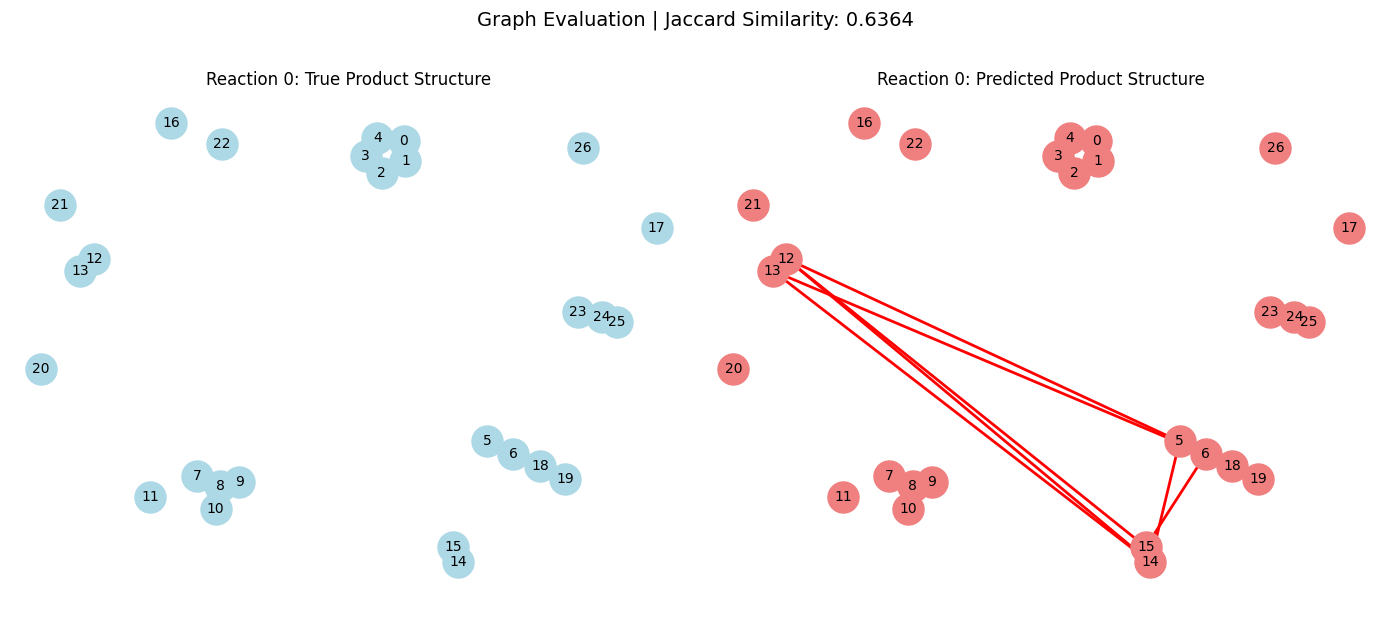

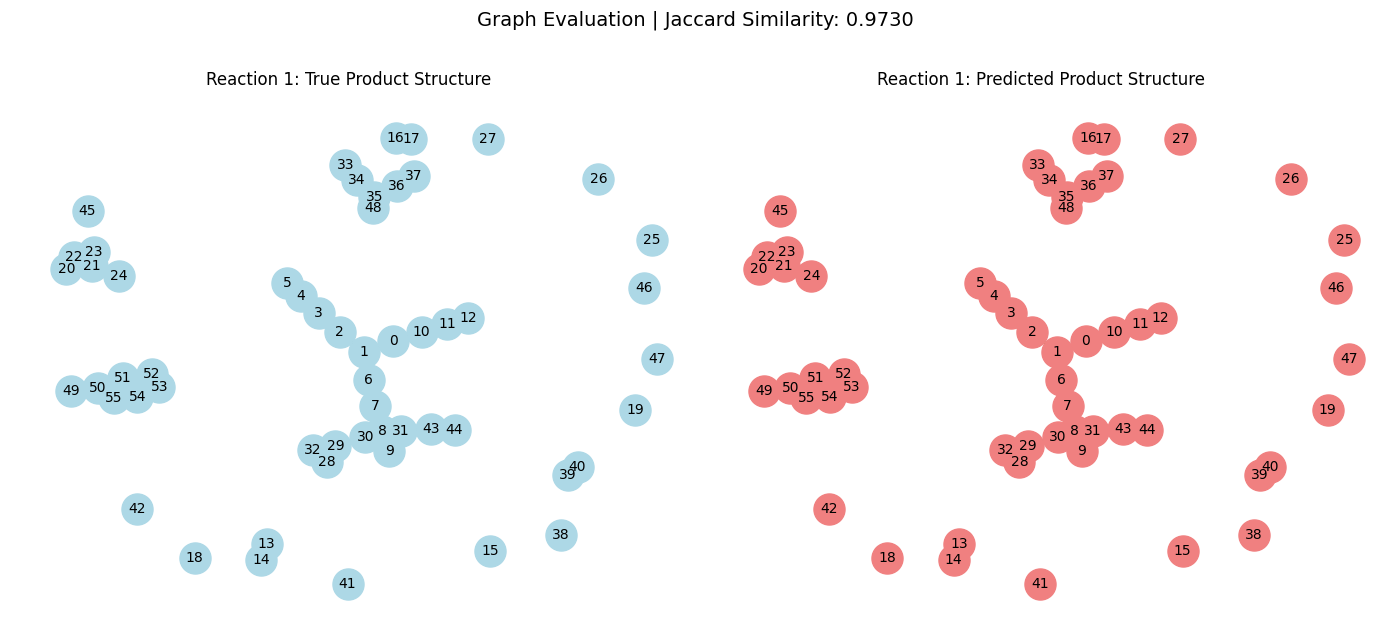

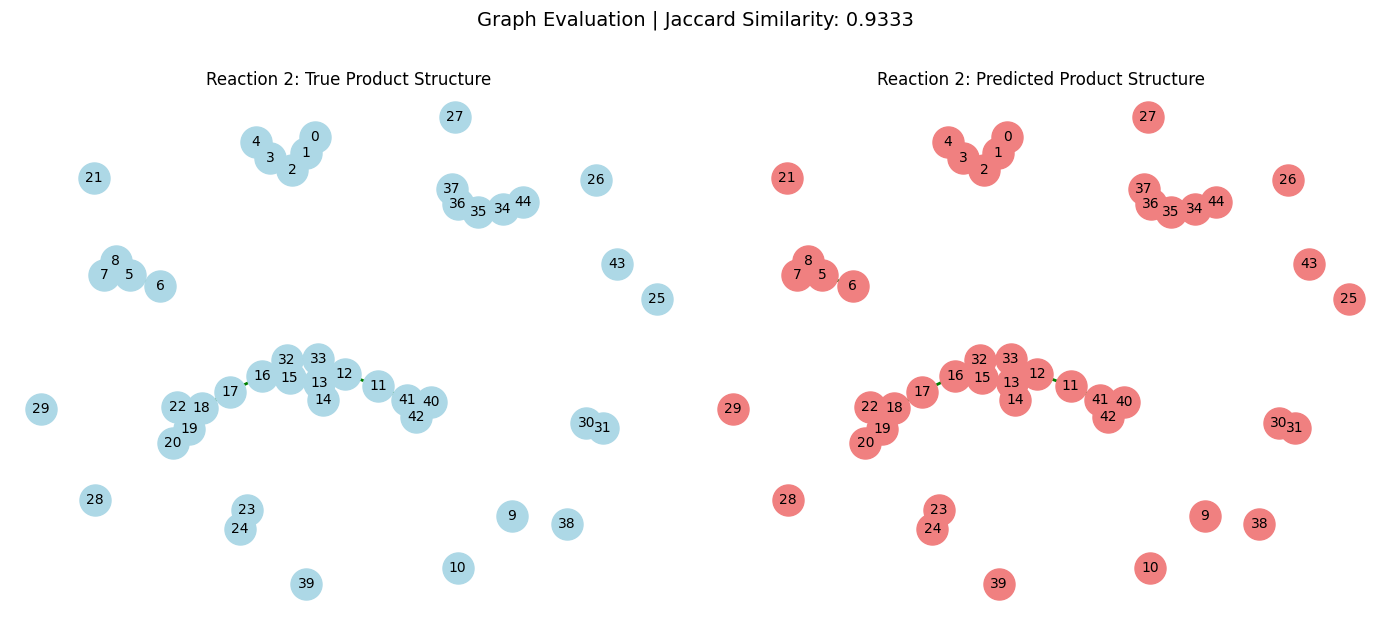

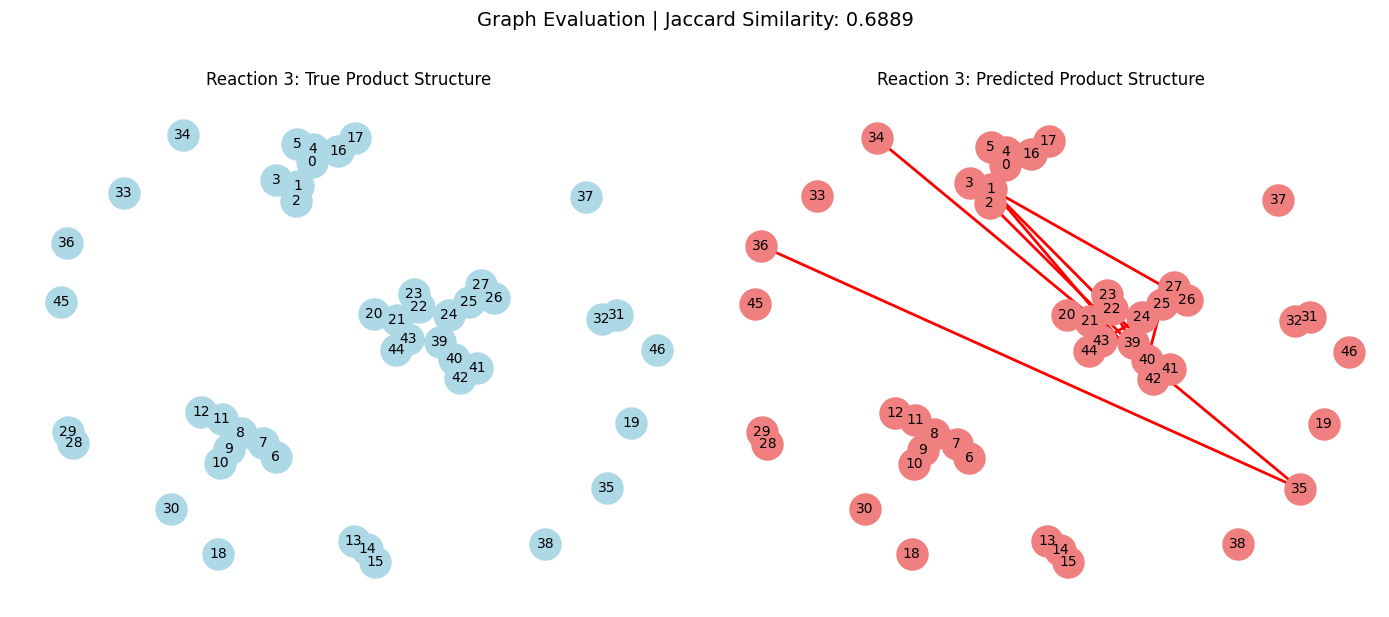

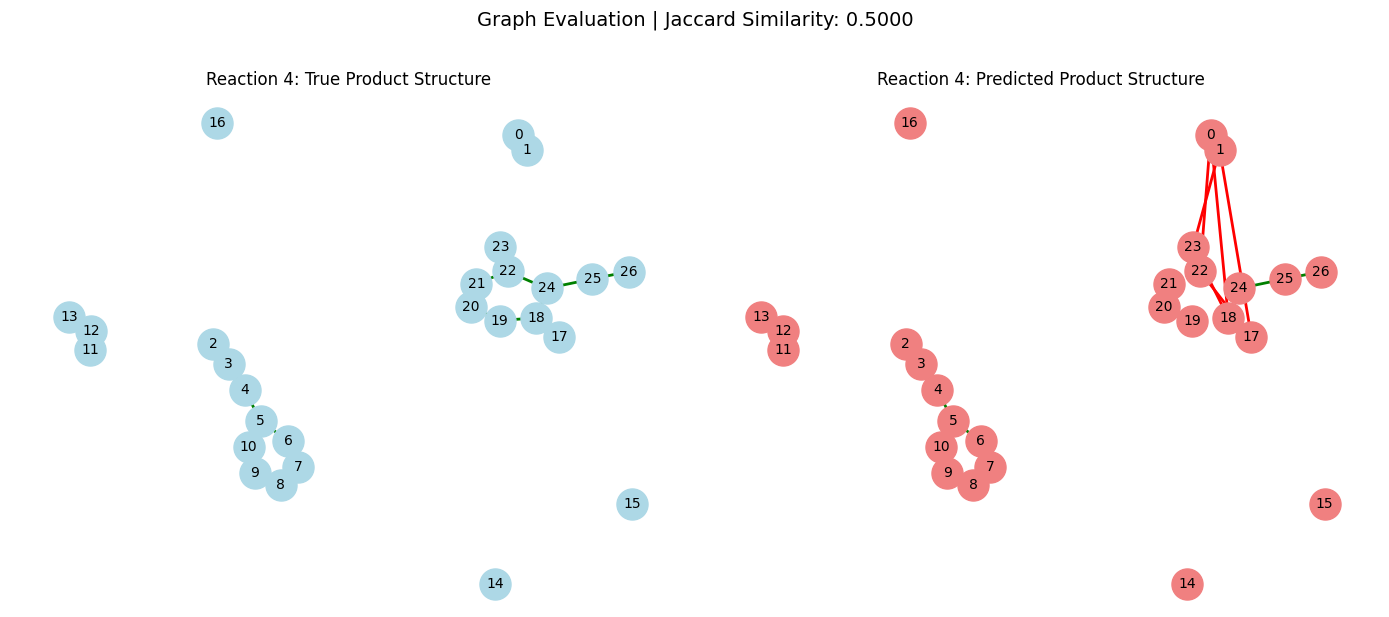


[!] Found a 100% Perfect Prediction at index 29! Visualizing structure:
True Mapped SMILES: [CH3:10][C:11]([CH2:12][CH:13]([CH2:14][CH3:15])[CH2:26][CH2:27][CH2:28][CH3:29])([CH3:24])[CH3:25].[CH3:1][CH2:2][CH3:3].[CH3:4][CH2:5][CH2:6][CH:7]([CH3:8])[CH3:9].[CH4:16].[CH4:17].[CH4:18].[CH4:19].[CH4:20].[CH4:21].[CH4:22].[CH4:23]
Pred Mapped SMILES: [CH3:10][C:11]([CH2:12][CH:13]([CH2:14][CH3:15])[CH2:26][CH2:27][CH2:28][CH3:29])([CH3:24])[CH3:25].[CH3:1][CH2:2][CH3:3].[CH3:4][CH2:5][CH2:6][CH:7]([CH3:8])[CH3:9].[CH4:16].[CH4:17].[CH4:18].[CH4:19].[CH4:20].[CH4:21].[CH4:22].[CH4:23]


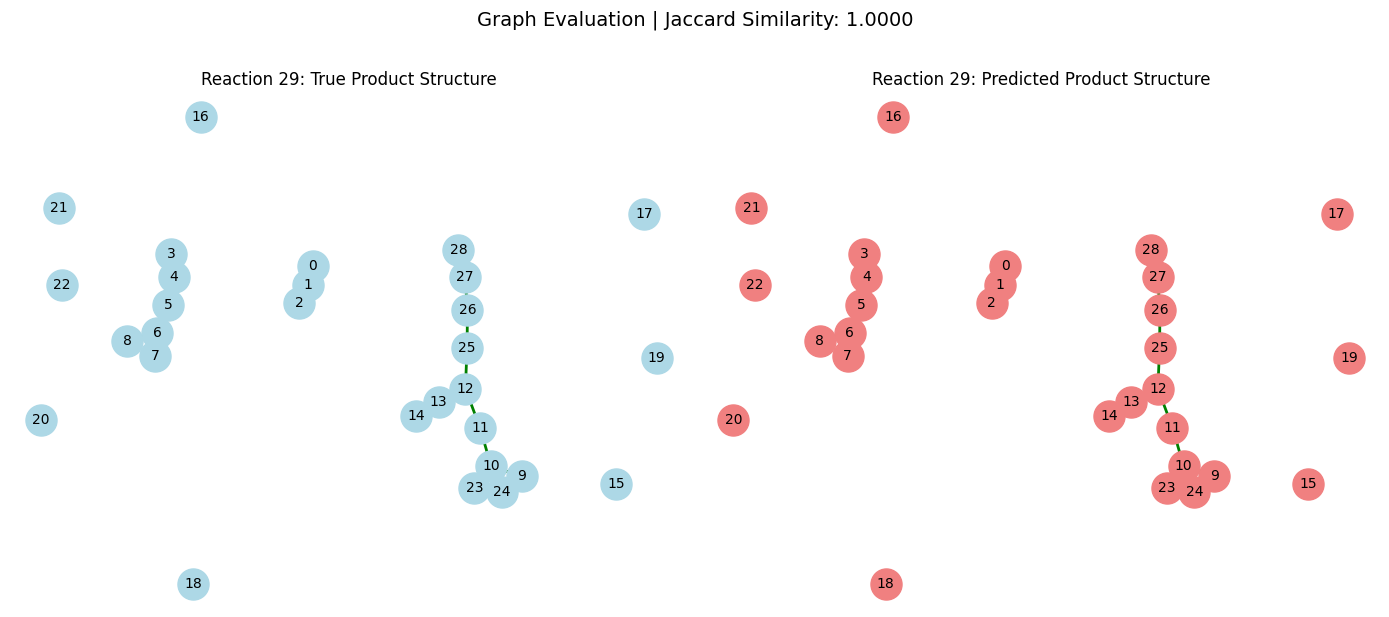


[Chemical Render] Flawless Structural Verification for Reaction 29:


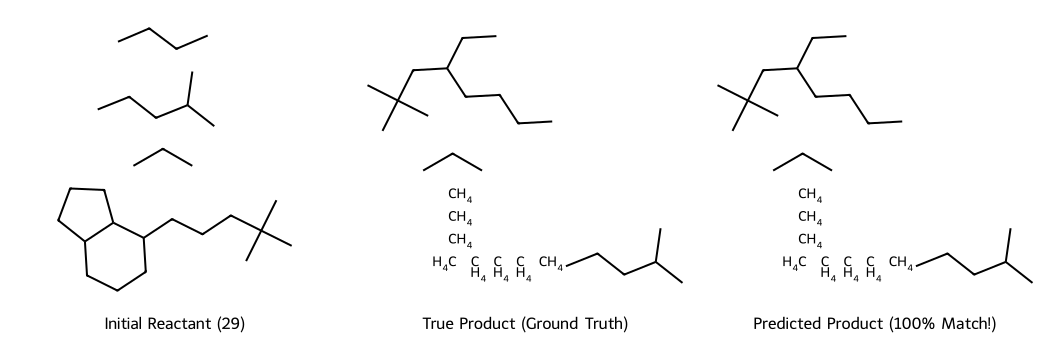


[!] Found a 100% Perfect Prediction at index 36! Visualizing structure:
True Mapped SMILES: [CH3:13][C:14](=[CH2:15])[CH2:16][CH3:17].[CH3:9][CH3:10].[CH4:11].[CH4:12].[CH4:18].[CH4:20].[CH4:3].[CH4:4].[CH4:5].[CH4:6].[CH4:7].[CH4:8].[NH2:1][CH3:2].[SH2:19]
Pred Mapped SMILES: [CH3:13][C:14](=[CH2:15])[CH2:16][CH3:17].[CH3:9][CH3:10].[CH4:11].[CH4:12].[CH4:18].[CH4:20].[CH4:3].[CH4:4].[CH4:5].[CH4:6].[CH4:7].[CH4:8].[NH2:1][CH3:2].[SH2:19]


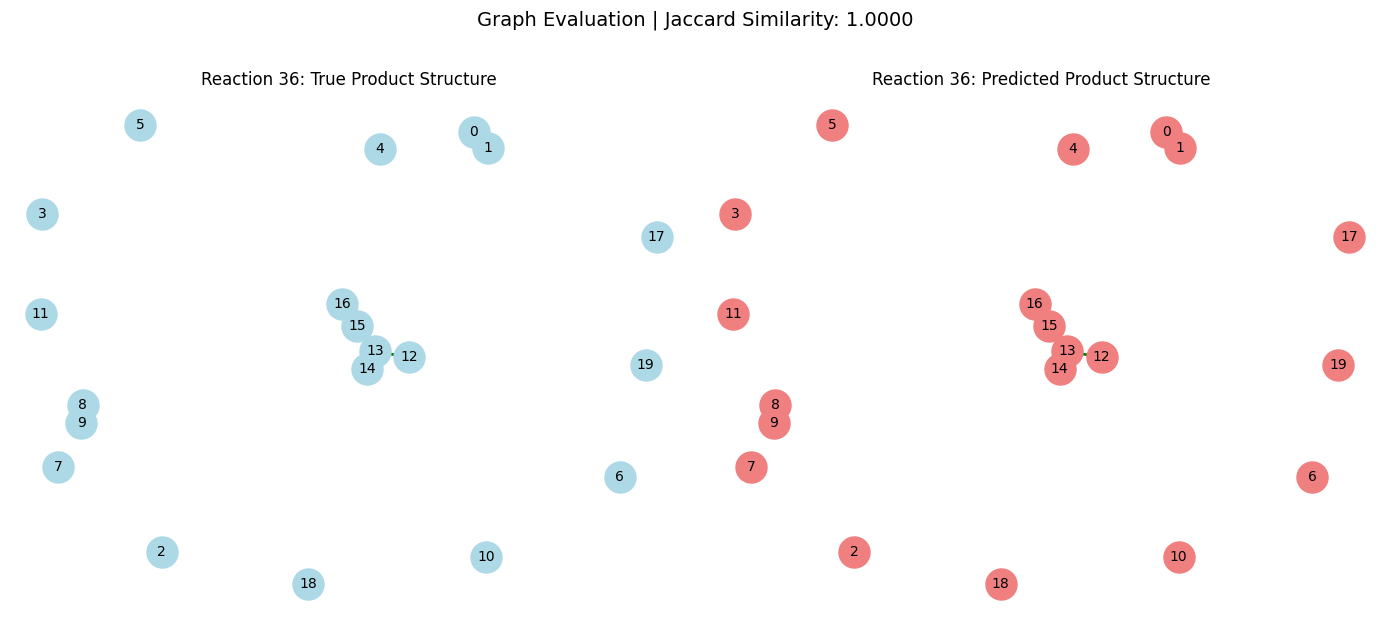


[Chemical Render] Flawless Structural Verification for Reaction 36:


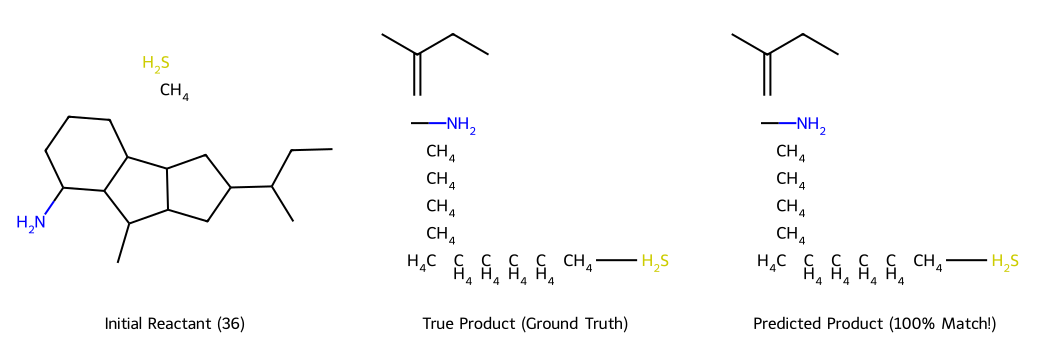


[!] Found a 100% Perfect Prediction at index 41! Visualizing structure:
True Mapped SMILES: [CH3:11][CH3:12].[CH3:20][CH3:21].[CH3:26][CH2:27][CH3:28].[CH3:8][CH3:9].[CH4:10].[CH4:13].[CH4:14].[CH4:15].[CH4:16].[CH4:17].[CH4:18].[CH4:24].[CH4:25].[CH4:29].[CH4:30].[CH4:31].[CH4:32].[CH4:33].[CH4:34].[CH4:35].[CH4:36].[CH4:37].[CH4:38].[CH4:39].[CH4:7].[CH:1]([CH3:2])([CH3:3])[CH3:4].[NH2:5][CH2:6][CH2:23][CH3:22].[NH3:19]
Pred Mapped SMILES: [CH3:11][CH3:12].[CH3:20][CH3:21].[CH3:26][CH2:27][CH3:28].[CH3:8][CH3:9].[CH4:10].[CH4:13].[CH4:14].[CH4:15].[CH4:16].[CH4:17].[CH4:18].[CH4:24].[CH4:25].[CH4:29].[CH4:30].[CH4:31].[CH4:32].[CH4:33].[CH4:34].[CH4:35].[CH4:36].[CH4:37].[CH4:38].[CH4:39].[CH4:7].[CH:1]([CH3:2])([CH3:3])[CH3:4].[NH2:5][CH2:6][CH2:23][CH3:22].[NH3:19]


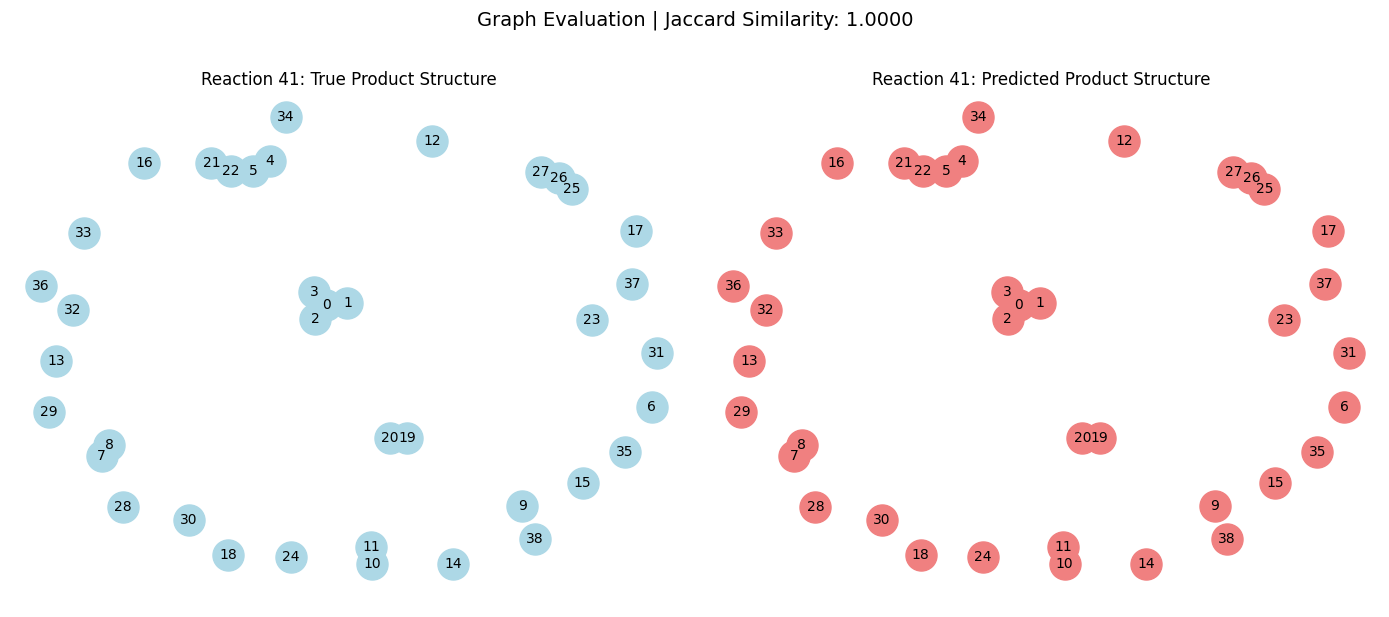


[Chemical Render] Flawless Structural Verification for Reaction 41:


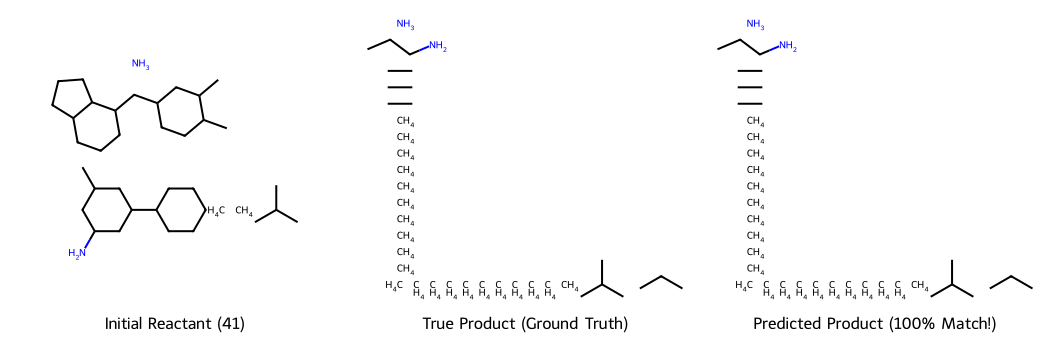


================ COMPARATIVE EVALUATION SUMMARY ================
Graphs Evaluated:                39994
Mean Structural Similarity:       0.7939
Max Graph Similarity Seen:        1.0000
Chemically Valid SMILES Rate:     41.14% (16455/39994)
----------------------------------------------------------------
Flawless Product Graph Accuracy:  5.05% (2021/39994)
Flawless Mapped SMILES Accuracy:  3.91% (1563/39994)


In [15]:

# --- SUBSET EXECUTION WITH EXPLICIT PERFECT-GRAPH HUNTING ---
model.eval()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)

MAX_EVAL_GRAPHS = 40000  # Scan a larger group to make sure we find a perfect match
NUM_VISUALIZATIONS = 5 # number of graphs to visualize

eval_subset = test_graphs[:MAX_EVAL_GRAPHS]

print(f"\n--- Running Graph Reconstruction on a Subset of {len(eval_subset)} Graphs ---")
similarity_scores = []
perfect_predictions_count = 0
max_similarity = 0.0
num_perfect_prediction_visualizations = 3 #number of perfect predictions to visualize
perfect_smiles_count = 0
valid_smiles_count = 0

for idx, orig_graph in enumerate(eval_subset):
    single_loader = StandardDataLoader([orig_graph], batch_size=1, collate_fn=reaction_collator)
    batch = next(iter(single_loader)).to(DEVICE)

    with torch.no_grad():
        logits = model(batch)
        preds = torch.argmax(logits, dim=1).cpu()

    pred_matrix = reconstruct_product_graph(orig_graph, preds)
    pred_smiles = convert_matrix_to_smiles(orig_graph, pred_matrix)

    if pred_smiles not in ["INVALID_VALENCY", "EMPTY_GRAPH", "UNPARSABLE_STRUCTURE"]:
        valid_smiles_count += 1

    # Reconstruct true target matrix
    true_matrix = torch.zeros((orig_graph.x.size(0), orig_graph.x.size(0)), dtype=torch.int)
    if orig_graph.edge_index.numel() > 0:
        row, col = orig_graph.edge_index
        true_matrix[row, col] = 1

    pairs = orig_graph.candidate_pairs.cpu()
    true_ys = orig_graph.y.cpu()
    for p_idx in range(pairs.size(1)):
        u, v = pairs[0, p_idx].item(), pairs[1, p_idx].item()
        if true_ys[p_idx].item() in [1, 2, 3]:
            true_matrix[u, v] = true_ys[p_idx].item()
            true_matrix[v, u] = true_ys[p_idx].item()
        elif true_ys[p_idx].item() == 4:
            true_matrix[u, v] = 0
            true_matrix[v, u] = 0

    true_mapped_smiles = convert_matrix_to_smiles(orig_graph, true_matrix)
    score = calculate_graph_similarity(true_matrix.numpy(), pred_matrix.numpy())
    similarity_scores.append(score)

    if score > max_similarity:
        max_similarity = score

    if score == 1.0:
        perfect_predictions_count += 1
        # Visualize the graph of the perfect prediction
        if perfect_predictions_count < num_perfect_prediction_visualizations + 1:
            print(f"\n[!] Found a 100% Perfect Prediction at index {idx}! Visualizing structure:")
            print(f"True Mapped SMILES: {true_mapped_smiles}")
            print(f"Pred Mapped SMILES: {pred_smiles}")
            visualize_prediction_vs_truth(orig_graph, pred_matrix, index=idx)
            visualize_chemical_reaction_comparison(orig_graph, pred_matrix, index=idx)

    # 4. Strict SMILES Identity Evaluation
    # If the text strings match completely, the chemical structure AND node locations are perfect
    if pred_smiles == true_mapped_smiles and true_mapped_smiles not in ["INVALID_VALENCY", "EMPTY_GRAPH"]:
        perfect_smiles_count += 1

    # Standard visualization for the initial samples
    if idx < NUM_VISUALIZATIONS:
        visualize_prediction_vs_truth(orig_graph, pred_matrix, index=idx)

mean_similarity = np.mean(similarity_scores)
perfect_accuracy = (perfect_predictions_count / len(eval_subset)) * 100
smiles_perfect_accuracy = (perfect_smiles_count / len(eval_subset)) * 100
validity_rate = (valid_smiles_count / len(eval_subset)) * 100

print("\n================ COMPARATIVE EVALUATION SUMMARY ================")
print(f"Graphs Evaluated:                {len(eval_subset)}")
print(f"Mean Structural Similarity:       {mean_similarity:.4f}")
print(f"Max Graph Similarity Seen:        {max_similarity:.4f}")
print(f"Chemically Valid SMILES Rate:     {validity_rate:.2f}% ({valid_smiles_count}/{len(eval_subset)})")
print(f"----------------------------------------------------------------")
print(f"Flawless Product Graph Accuracy:  {perfect_accuracy:.2f}% ({perfect_predictions_count}/{len(eval_subset)})")
print(f"Flawless Mapped SMILES Accuracy:  {smiles_perfect_accuracy:.2f}% ({perfect_smiles_count}/{len(eval_subset)})")
print("==================================================================")

## 11. Plot Training Metrics

Simple plots of the loss, prediction accuracy, precision, and recall per 100 batches

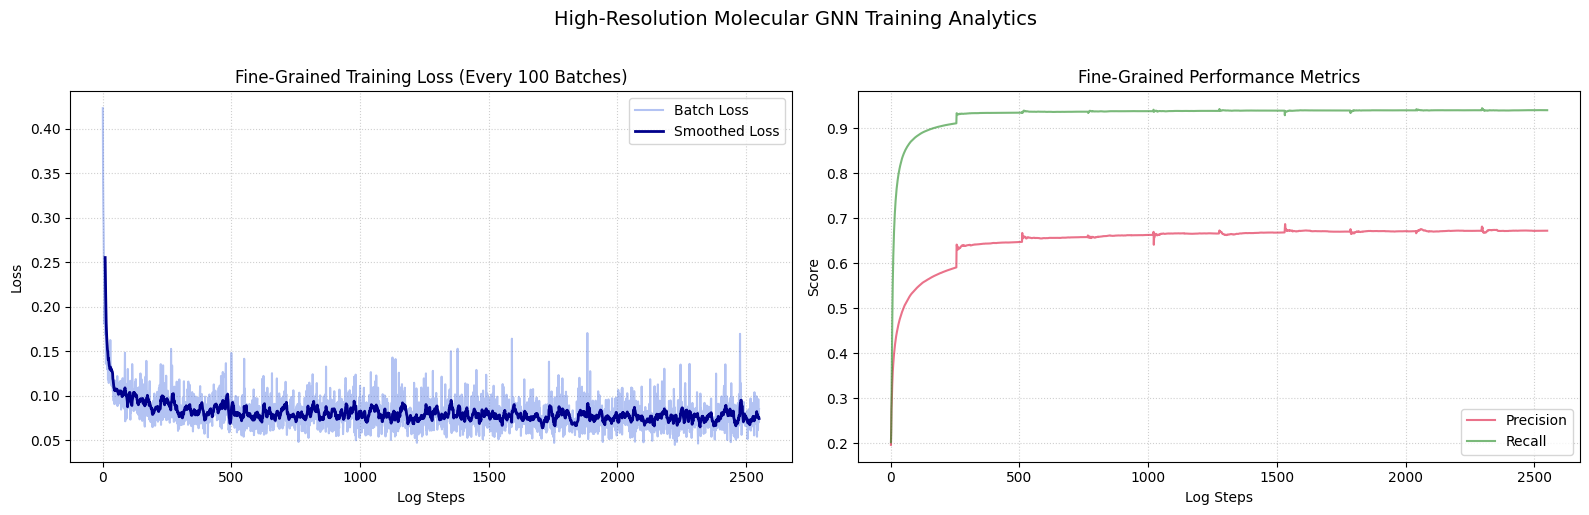

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
iter_range = range(1, len(fine_grained_history["loss"]) + 1)

# Plot 1: Fine-grained Loss
axes[0].plot(iter_range, fine_grained_history["loss"], label='Batch Loss', color='royalblue', alpha=0.4)
# Simple moving average for smoothing
smooth_loss = np.convolve(fine_grained_history["loss"], np.ones(10)/10, mode='valid')
axes[0].plot(range(10, len(smooth_loss)+10), smooth_loss, label='Smoothed Loss', color='darkblue', linewidth=2)
axes[0].set_title('Fine-Grained Training Loss (Every 100 Batches)', fontsize=12)
axes[0].set_xlabel('Log Steps', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Fine-grained Metrics
axes[1].plot(iter_range, fine_grained_history["precision"], label='Precision', color='crimson', alpha=0.6)
axes[1].plot(iter_range, fine_grained_history["recall"], label='Recall', color='forestgreen', alpha=0.6)
axes[1].set_title('Fine-Grained Performance Metrics', fontsize=12)
axes[1].set_xlabel('Log Steps', fontsize=10)
axes[1].set_ylabel('Score', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('High-Resolution Molecular GNN Training Analytics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 11.1 High-Level Training Summary (Per-Epoch)

Epoch-level plots of loss, precision, accuracy, and recall.

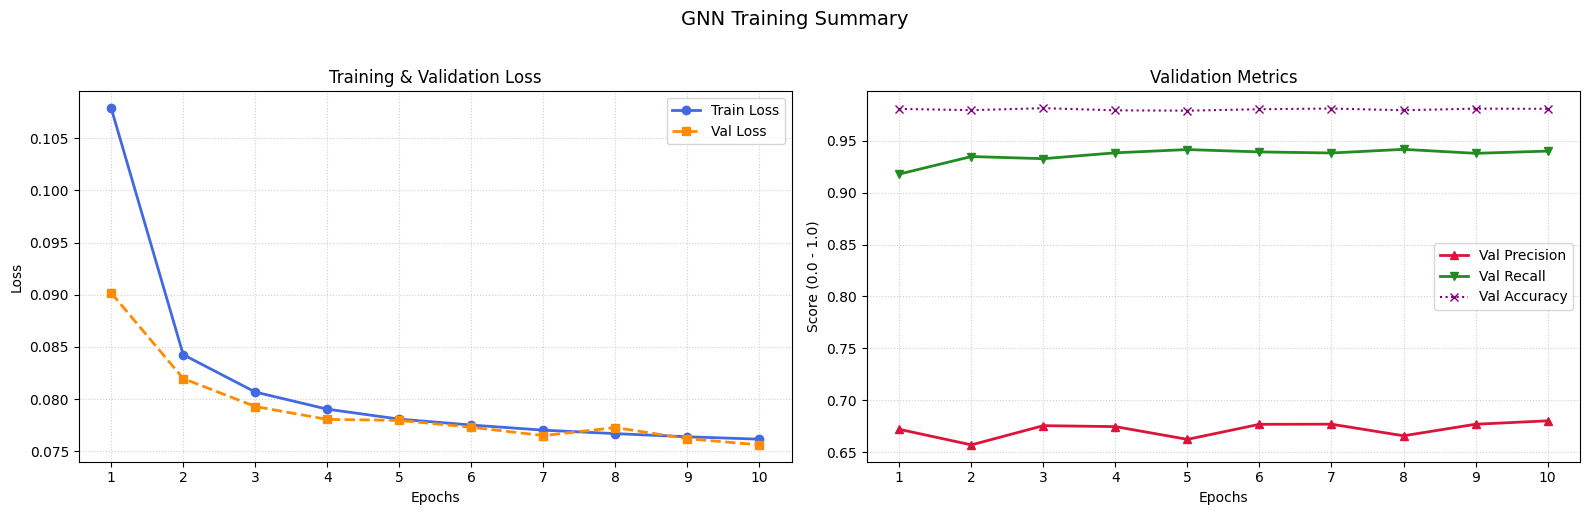

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Plot 1: Epoch-level Loss
axes[0].plot(epochs_range, history["train_loss"], label='Train Loss', color='royalblue', marker='o', linewidth=2)
axes[0].plot(epochs_range, history["val_loss"], label='Val Loss', color='darkorange', marker='s', linewidth=2, linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=12)
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Epoch-level Performance
axes[1].plot(epochs_range, history["val_prec"], label='Val Precision', color='crimson', marker='^', linewidth=2)
axes[1].plot(epochs_range, history["val_rec"], label='Val Recall', color='forestgreen', marker='v', linewidth=2)
axes[1].plot(epochs_range, history["val_acc"], label='Val Accuracy', color='purple', marker='x', linewidth=1.5, linestyle=':')
axes[1].set_title('Validation Metrics', fontsize=12)
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Score (0.0 - 1.0)', fontsize=10)
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('GNN Training Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()